In [1]:
import os
import kagglehub
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

print("--- Step 1: Loading & Merging Data ---")
# 1. Download dataset
path = kagglehub.dataset_download("olistbr/brazilian-ecommerce")

# 2. Load necessary tables (Added products table for the volume calculation)
orders = pd.read_csv(os.path.join(path, "olist_orders_dataset.csv"))
items = pd.read_csv(os.path.join(path, "olist_order_items_dataset.csv"))
products = pd.read_csv(os.path.join(path, "olist_products_dataset.csv"))

# 3. Merge into a single master dataframe
df = orders.merge(items, on='order_id').merge(products, on='product_id')

print("--- Step 2: Data Cleaning & Feature Engineering ---")
# Filter for delivered orders only
df = df[df['order_status'] == 'delivered'].copy()

# Drop rows missing crucial date or product dimension information
df.dropna(subset=['order_delivered_customer_date', 'order_estimated_delivery_date', 
                  'product_length_cm', 'product_height_cm', 'product_width_cm'], inplace=True)

# Convert strings to datetime objects
df['order_delivered_customer_date'] = pd.to_datetime(df['order_delivered_customer_date'])
df['order_estimated_delivery_date'] = pd.to_datetime(df['order_estimated_delivery_date'])

# Feature 1: Was it delayed? (1 = Yes, 0 = No)
df['delivery_time_diff'] = (df['order_delivered_customer_date'] - df['order_estimated_delivery_date']).dt.days
df['is_delayed'] = np.where(df['delivery_time_diff'] > 0, 1, 0)

# Feature 2: Product Volume (cm³)
df['product_volume_cm3'] = df['product_length_cm'] * df['product_height_cm'] * df['product_width_cm']

print(f"Data Ready! Total rows for analysis: {len(df)}")

/Users/apple/.pyenv/versions/3.10.13/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


--- Step 1: Loading & Merging Data ---
--- Step 2: Data Cleaning & Feature Engineering ---
Data Ready! Total rows for analysis: 110171


--- Step 3: Exploratory Data Analysis (EDA) ---


/var/folders/g0/lxz8gk8x2bv0n5hs9p6ws6mm0000gn/T/ipykernel_37109/1283423790.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='is_delayed', palette='Set2')


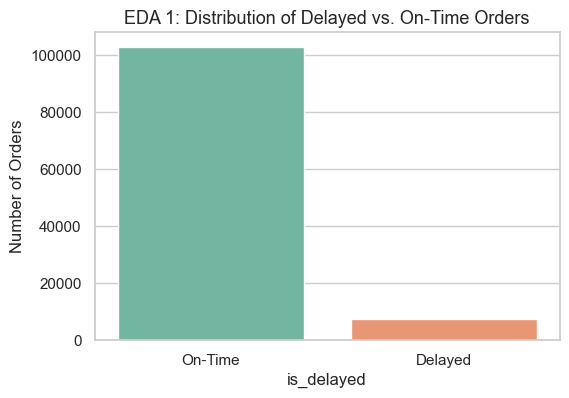

/var/folders/g0/lxz8gk8x2bv0n5hs9p6ws6mm0000gn/T/ipykernel_37109/1283423790.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='is_delayed', y='product_volume_cm3', palette='coolwarm', showfliers=False)


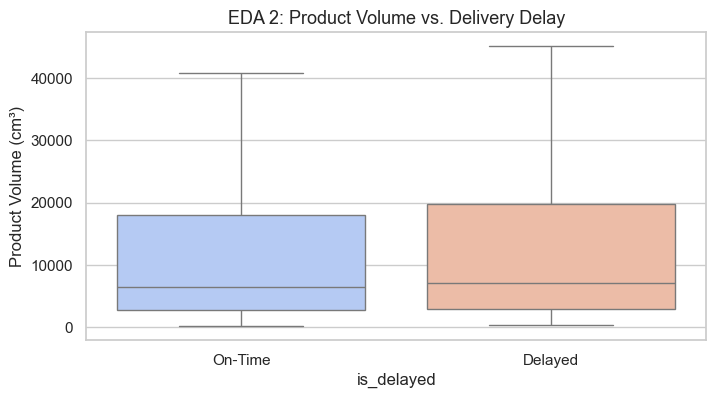

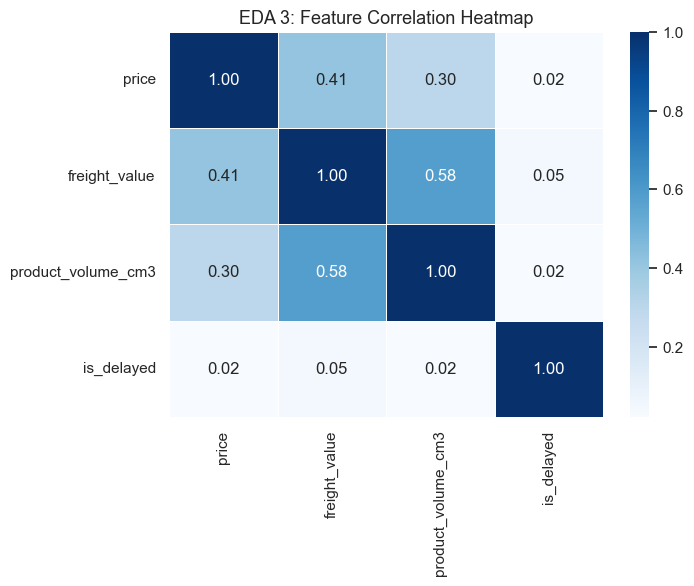

In [2]:
print("--- Step 3: Exploratory Data Analysis (EDA) ---")
sns.set_theme(style="whitegrid")

# 1. Target Distribution
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='is_delayed', palette='Set2')
plt.title("EDA 1: Distribution of Delayed vs. On-Time Orders", fontsize=13)
plt.xticks([0, 1], ['On-Time', 'Delayed'])
plt.ylabel("Number of Orders")
plt.show()

# 2. Volume vs. Delays
plt.figure(figsize=(8, 4))
sns.boxplot(data=df, x='is_delayed', y='product_volume_cm3', palette='coolwarm', showfliers=False)
plt.title("EDA 2: Product Volume vs. Delivery Delay", fontsize=13)
plt.xticks([0, 1], ['On-Time', 'Delayed'])
plt.ylabel("Product Volume (cm³)")
plt.show()

# 3. Correlation Heatmap
plt.figure(figsize=(7, 5))
numeric_cols = ['price', 'freight_value', 'product_volume_cm3', 'is_delayed']
sns.heatmap(df[numeric_cols].corr(), annot=True, cmap='Blues', fmt='.2f', linewidths=0.5)
plt.title("EDA 3: Feature Correlation Heatmap", fontsize=13)
plt.show()

In [3]:
print("--- Step 4: Machine Learning Modeling ---")

# Define features and target
features = ['price', 'freight_value', 'product_volume_cm3']
X = df[features]
y = df['is_delayed']

# Train/Test Split (80% Training, 20% Testing)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Initialize Random Forest
rf_model = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1, class_weight='balanced')

# Train the model
print("Training Random Forest Classifier...")
rf_model.fit(X_train, y_train)

# Evaluate
y_pred = rf_model.predict(X_test)
print(f" Model Accuracy: {accuracy_score(y_test, y_pred):.2%}")
print("\n--- Classification Report ---")
print(classification_report(y_test, y_pred))

--- Step 4: Machine Learning Modeling ---
Training Random Forest Classifier...
 Model Accuracy: 89.30%

--- Classification Report ---
              precision    recall  f1-score   support

           0       0.95      0.94      0.94     20594
           1       0.22      0.25      0.23      1441

    accuracy                           0.89     22035
   macro avg       0.58      0.59      0.59     22035
weighted avg       0.90      0.89      0.90     22035



--- Step 5: Storytelling & Business Insights ---


/var/folders/g0/lxz8gk8x2bv0n5hs9p6ws6mm0000gn/T/ipykernel_37109/436215583.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=feat_df, x='Importance', y='Feature', palette='magma')


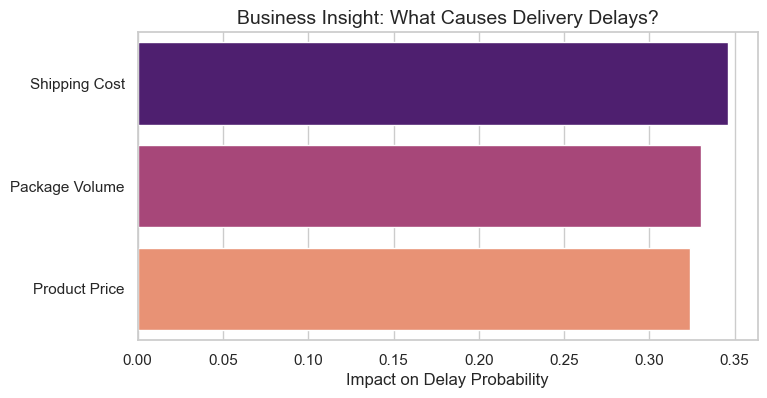

In [4]:
print("--- Step 5: Storytelling & Business Insights ---")

# Extract Feature Importances
importances = rf_model.feature_importances_
feat_df = pd.DataFrame({'Feature': features, 'Importance': importances}).sort_values(by='Importance', ascending=False)

# Clean up feature names for the presentation chart
feat_df['Feature'] = feat_df['Feature'].replace({
    'freight_value': 'Shipping Cost',
    'product_volume_cm3': 'Package Volume',
    'price': 'Product Price'
})

# Plot
plt.figure(figsize=(8, 4))
sns.barplot(data=feat_df, x='Importance', y='Feature', palette='magma')
plt.title("Business Insight: What Causes Delivery Delays?", fontsize=14)
plt.xlabel("Impact on Delay Probability")
plt.ylabel("")
plt.show()

Insight: Package volume and shipping costs are the strongest indicators of whether a package will be delayed.